# **AirBNB Price Prediction**

## Collaborateurs
-
-
-
-

## Dépot github : [PIA projet final M102](https://github.com/Thekorzeremi/PIA_Projet_final_M102)

In [1]:
# imports and variables constantes
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, joblib
from pathlib import Path
import gzip
import shutil
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from scipy.stats import loguniform, randint

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

print("Setup OK · Versions :")
import sklearn; print(f"  scikit-learn : {sklearn.__version__}")
print(f"  pandas       : {pd.__version__}")
print(f"  numpy        : {np.__version__}")

Setup OK · Versions :
  scikit-learn : 1.8.0
  pandas       : 3.0.3
  numpy        : 2.4.6


In [2]:
# fonctions utilitaires
def decompress_gz(fichier_entree: Path):
    with gzip.open(fichier_entree, 'rb') as f_in:
        with open(fichier_entree.with_suffix(''), 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

### Dataset

In [3]:
# Chemin vers les fichiers de dataset sur Paris
archive_dataset = "data/listings.csv.gz"
csv_fallback = "data/listings.csv"

In [4]:
# chargement des data
try:
    path = Path(archive_dataset)
    decompress_gz(path)
finally:
    df = pd.read_csv(csv_fallback)
    print(f"✓ Chargé depuis CSV : {df.shape}")

✓ Chargé depuis CSV : (84055, 79)


In [5]:
df_data = df.copy()
df_data.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,...,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3109,https://www.airbnb.com/rooms/3109,20250606142312,2025-06-20,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,https://www.airbnb.com/users/show/3631,Anne,2008-10-14,"Paris, France",NaN,...,2025-06-03,5.00,5.00,5.00,5.00,5.00,5.00,5.00,7511409139079,f,1,1,0,0,0.08
1,5396,https://www.airbnb.com/rooms/5396,20250606142312,2025-06-19,city scrape,Your perfect Paris studio on Île Saint-Louis,"Cozy, well-appointed and graciously designed s...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,https://www.airbnb.com/users/show/7903,Borzou,2009-02-14,"Paris, France",We have spent a lot of time traveling for work...,...,2025-06-05,4.62,4.64,4.59,4.81,4.85,4.95,4.59,7510402838018,f,1,1,0,0,2.32
2,7397,https://www.airbnb.com/rooms/7397,20250606142312,2025-06-20,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,https://www.airbnb.com/users/show/2626,Franck,2008-08-30,"Paris, France","I am a writer,54, author of novels, books of l...",...,2025-06-03,4.73,4.80,4.45,4.92,4.89,4.94,4.74,7510400829623,f,1,1,0,0,2.20


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84055 entries, 0 to 84054
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            84055 non-null  int64  
 1   listing_url                                   84055 non-null  str    
 2   scrape_id                                     84055 non-null  int64  
 3   last_scraped                                  84055 non-null  str    
 4   source                                        84055 non-null  str    
 5   name                                          84055 non-null  str    
 6   description                                   81177 non-null  str    
 7   neighborhood_overview                         41178 non-null  str    
 8   picture_url                                   84054 non-null  str    
 9   host_id                                       84055 non-null  int64  
 1

### Suppression de colonnes inutiles

In [7]:
# On dégage la colonne Id qui n'a aucune valeur prédictive
columns_id = [col for col in df_data.columns if col.endswith('id') ]
print(f"Shape avant: {df_data.shape}")
print('Colonnes d\'id :', columns_id) 
for c in columns_id:
    df_data = df_data.drop(columns=[c])
print(f"Shape après: {df_data.shape}")

Shape avant: (84055, 79)
Colonnes d'id : ['id', 'scrape_id', 'host_id']
Shape après: (84055, 76)


In [8]:
# Sélection des colonnes de type 'object'
df_objects = df_data.select_dtypes(include=['object'])

# Afficher les premières lignes pour vérifier les valeurs
print(df_objects.head())

# Optionnel : obtenir un résumé rapide des valeurs uniques par colonne
display(df_objects.describe())

                         listing_url last_scraped           source                                             name                                        description  \
0  https://www.airbnb.com/rooms/3109   2025-06-20      city scrape                                     zen and calm  Lovely Appartment with one bedroom with a Quee...   
1  https://www.airbnb.com/rooms/5396   2025-06-19      city scrape     Your perfect Paris studio on Île Saint-Louis  Cozy, well-appointed and graciously designed s...   
2  https://www.airbnb.com/rooms/7397   2025-06-20      city scrape                 MARAIS - 2ROOMS APT - 2/4 PEOPLE          VERY CONVENIENT, WITH THE BEST LOCATION !   
3  https://www.airbnb.com/rooms/7964   2025-06-18  previous scrape                     Sunny apartment with balcony  We are renting our a spacious, sunny fully fur...   
4  https://www.airbnb.com/rooms/9359   2025-06-18      city scrape  Cozy, Central Paris: WALK or VELIB EVERYWHERE !  Location! Location! Location! Jus

,listing_url,last_scraped,source,name,description,neighborhood_overview,picture_url,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,...,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,property_type,room_type,bathrooms_text,amenities,price,has_availability,calendar_last_scraped,first_review,last_review,license,instant_bookable
count,84055,84055,84055,84055,81177,41178,84054,84055,84031,84029,66876,37408,52663,52663,57913,...,84029,84029,41178,84055,84055,84055,83982,84055,53963,79903,84055,64498,64498,66434,84055
unique,84055,5,2,77999,77228,35729,83370,60884,11376,5381,1935,21566,4,93,101,...,2,2,1,20,58,4,36,73151,1634,2,5,4598,3449,54163,2
top,https://www.airbnb.com/rooms/3109,2025-06-18,city scrape,Appartement,"Make life easier at this peaceful, centrally l...",.,https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/314994947,Joffrey Sally,2019-12-06,"Paris, France","We’re Blueground, a global proptech company wi...",within an hour,100%,100%,...,t,t,Neighborhood highlights,Buttes-Montmartre,Entire rental unit,Entire home/apt,1 bath,"[""Kitchen"", ""Wifi"", ""Washer"", ""Smoke alarm"", ""...",$90.00,t,2025-06-18,2024-08-04,2025-06-01,"Available with a mobility lease only (""bail mo...",f
freq,1,35435,54313,91,116,84,7,835,1018,853,57893,835,31859,36805,21028,...,81146,75982,41178,8943,69871,74532,61261,339,801,79902,35435,227,2510,7482,61484


In [9]:
# verifions les NA
df_data['bathrooms'].isnull().sum()

np.int64(29758)

In [10]:
# Columns inutiles
print(f"Shape avant: {df_data.shape}")
cols_to_drop = [
    'listing_url', 'last_scraped','source', 'name', 'picture_url', 'host_url', 'host_name', 
    'neighbourhood_group_cleansed', 'beds', 'calendar_updated', 
    'description', 'neighborhood_overview', 'neighbourhood', 'host_about', 
    'host_thumbnail_url', 'host_picture_url', 'minimum_nights_avg_ntm', 
    'maximum_nights_avg_ntm', 'calendar_last_scraped', 'has_availability', 
    'reviews_per_month', 'license', 'host_neighbourhood', 'host_location',
    'host_since', 'first_review', 'last_review', 'host_verifications',
    'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 
    'maximum_minimum_nights', 'minimum_maximum_nights',	'maximum_maximum_nights',
]
# On utilise errors='ignore' au cas où certaines auraient déjà été supprimées
df_data = df_data.drop(columns=cols_to_drop, errors='ignore')
print(f"Shape après: {df_data.shape}")

Shape avant: (84055, 76)
Shape après: (84055, 42)


**Pourquoi on les supprime:**


### rédigeons


In [11]:
# Vérification
print("Shape :", df_data.shape)
display(df_data.describe())
df_data.info()

Shape : (84055, 42)


,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
count,84029.000000,84029.000000,84055.000000,84055.000000,84055.000000,54297.000000,76918.000000,84055.000000,84055.000000,84055.000000,84055.000000,84055.000000,84055.000000,84055.000000,84055.000000,84055.000000,84055.000000,5.396300e+04,64498.000000,64486.000000,64489.000000,64479.000000,64488.000000,64480.000000,64479.000000,84055.000000,84055.000000,84055.000000,84055.000000
mean,31.938843,41.159861,48.864047,2.342917,3.225198,1.211503,1.343457,6.888609,18.918613,31.091642,128.560859,25.854726,6.643293,0.690072,72.182785,5.692975,61.367700,1.817894e+04,4.732790,4.776988,4.667760,4.814846,4.833622,4.823588,4.631523,25.369758,24.193016,1.044031,0.014586
std,120.838795,157.249944,0.018094,0.034203,1.684463,0.555283,0.909540,9.340243,20.726749,32.289525,131.288844,59.659294,12.886168,1.416168,73.647144,11.875125,85.354511,6.508574e+04,0.389992,0.368886,0.438217,0.354538,0.354508,0.303654,0.430997,97.944143,96.282841,10.727246,0.259222
min,0.000000,0.000000,48.815890,2.229896,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,48.850758,2.320790,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,4.640000,4.710000,4.540000,4.780000,4.810000,4.770000,4.500000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,2.000000,48.865321,2.346677,3.000000,1.000000,1.000000,2.000000,11.000000,21.000000,80.000000,7.000000,1.000000,0.000000,47.000000,0.000000,10.000000,6.240000e+03,4.840000,4.880000,4.800000,4.920000,4.950000,4.920000,4.730000,1.000000,1.000000,0.000000,0.000000
75%,4.000000,6.000000,48.878630,2.367945,4.000000,1.000000,2.000000,12.000000,36.000000,60.000000,260.000000,26.000000,8.000000,1.000000,147.000000,6.000000,104.000000,2.079650e+04,5.000000,5.000000,4.980000,5.000000,5.000000,5.000000,4.890000,3.000000,2.000000,0.000000,0.000000
max,7954.000000,8721.000000,48.901670,2.468360,16.000000,42.000000,41.000000,30.000000,60.000000,90.000000,365.000000,3807.000000,732.000000,52.000000,198.000000,786.000000,255.000000,3.655680e+06,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,835.000000,835.000000,166.000000,9.000000


<class 'pandas.DataFrame'>
RangeIndex: 84055 entries, 0 to 84054
Data columns (total 42 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_response_time                            52663 non-null  str    
 1   host_response_rate                            52663 non-null  str    
 2   host_acceptance_rate                          57913 non-null  str    
 3   host_is_superhost                             82227 non-null  str    
 4   host_listings_count                           84029 non-null  float64
 5   host_total_listings_count                     84029 non-null  float64
 6   host_has_profile_pic                          84029 non-null  str    
 7   host_identity_verified                        84029 non-null  str    
 8   neighbourhood_cleansed                        84055 non-null  str    
 9   latitude                                      84055 non-null  float64
 1

In [12]:
# verifions les NA
df_data.isnull().sum()

host_response_time                              31392
host_response_rate                              31392
host_acceptance_rate                            26142
host_is_superhost                                1828
host_listings_count                                26
host_total_listings_count                          26
host_has_profile_pic                               26
host_identity_verified                             26
neighbourhood_cleansed                              0
latitude                                            0
longitude                                           0
property_type                                       0
room_type                                           0
accommodates                                        0
bathrooms                                       29758
bathrooms_text                                     73
bedrooms                                         7137
amenities                                           0
price                       

### Parsing 

In [13]:
# Parsing du prix 
df_data['price'] = df_data['price'].str.replace(r'[\$,]', '', regex=True).astype(float)

In [14]:

# Parsing de colonnes contenant des valeurs en pourcentage mais sous format str 
df_data['host_acceptance_rate'] = df_data['host_acceptance_rate'].str.replace('%', '', regex=False).astype('Int64')
df_data['host_response_rate'] = df_data['host_response_rate'].str.replace('%', '', regex=False).astype('Int64')

In [15]:
# Parsing de bathrooms_text
extracted_bathrooms = df_data['bathrooms_text'].str.extract(r'(\d+\.?\d*)')[0].astype(float)

# Remplir les valeurs manquantes (NaN) dans 'bathrooms' avec les valeurs extraites
# Si 'bathrooms' a déjà une valeur, on la garde. Si c'est NaN, on prend l'extraction.
df_data['bathrooms'] = df_data['bathrooms'].fillna(extracted_bathrooms)

# Traitement spécifique pour les cas particuliers (ex: "Half-bath" qui devient souvent NaN)
# Si après l'étape précédente, il reste des NaN et que le texte contenait "half"
df_data.loc[df_data['bathrooms'].isna() & df_data['bathrooms_text'].str.contains('half', case=False, na=False), 'bathrooms'] = 0.5

# Nettoyage final : Remplacer les restants par 0 si nécessaire (selon votre logique métier)
df_data['bathrooms'] = df_data['bathrooms'].fillna(0)

# On supprime la colonne texte après avoir récupéré les infos
df_data = df_data.drop(columns=['bathrooms_text'])

In [16]:
# colonnes à changer en binaire
cols_bool = ['host_has_profile_pic', 'host_identity_verified', 'host_is_superhost', ]
for col in cols_bool:
    # Le map transforme 't' en 1 et 'f' en 0. Les valeurs manquantes restent NaN pour le moment.
    df_data[col] = df_data[col].map({'t': 1, 'f': 0})

In [17]:
# Sélection des colonnes de type 'object'
df_amen = df_data['amenities']

# Afficher les premières lignes pour vérifier les valeurs
print(df_amen[1])

# Optionnel : obtenir un résumé rapide des valeurs uniques par colonne
display(df_amen.describe())

["Shampoo", "Long term stays allowed", "Portable fans", "Washer", "Oven", "Clothing storage: closet", "Hair dryer", "Stove", "Fire extinguisher", "Coffee", "Coffee maker: espresso machine, pour-over coffee", "Drying rack for clothing", "Bed linens", "Baking sheet", "Host greets you", "First aid kit", "Kitchen", "Dishes and silverware", "Toaster", "Shower gel", "Body soap", "Cleaning products", "Hangers", "Wifi", "Wine glasses", "Hot water kettle", "TV with standard cable", "Books and reading material", "Hot water", "Iron", "Heating", "Smoke alarm", "Essentials", "Extra pillows and blankets", "Dedicated workspace", "Cooking basics", "Refrigerator"]


count                                                 84055
unique                                                73151
top       ["Kitchen", "Wifi", "Washer", "Smoke alarm", "...
freq                                                    339
Name: amenities, dtype: object

In [18]:
# Parsing des amenities
# On définit un dictionnaire avec le nom de la future colonne et le mot-clé à chercher

print(f"Shape avant: {df_data.shape}")
amenities_to_extract = {
    'has_wifi': 'Wifi',
    'has_tv': 'TV',
    'has_kitchen': 'Kitchen',
    'has_ac': 'Air conditioning',
    'has_elevator': 'Elevator',
    'has_shampoo': 'Shampoo',
    'has_washer': 'Washer',
    'has_oven': 'Oven',
    'has_stove': 'Stove',
    'has_hair_dryer': 'Hair dryer',
    'has_iron': 'Iron',
    'has_heating': 'Heating',
    'has_coffee_maker': 'Coffee maker',
    'has_refrigerator': 'Refrigerator',
    'has_workspace': 'Dedicated workspace',
    'has_fire_extinguisher': 'Fire extinguisher',
    'has_smoke_alarm': 'Smoke alarm',
    'has_first_aid': 'First aid kit'
}

for col_name, keyword in amenities_to_extract.items():
    # str.contains cherche le mot-clé. na=False permet de mettre 0 si la ligne est NaN.
    # astype(int) transforme le True/False en 1/0
    df_data[col_name] = df_data['amenities'].str.contains(keyword, case=False, na=False).astype(int)

# On supprime la colonne JSON brute qui n'est plus utile pour le modèle
df_data = df_data.drop(columns=['amenities'])
print(f"Shape après: {df_data.shape}")
df_data.head(5)

Shape avant: (84055, 41)
Shape après: (84055, 58)


,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,...,has_ac,has_elevator,has_shampoo,has_washer,has_oven,has_stove,has_hair_dryer,has_iron,has_heating,has_coffee_maker,has_refrigerator,has_workspace,has_fire_extinguisher,has_smoke_alarm,has_first_aid
0,within an hour,100,100,0.0,1.0,1.0,1.0,1.0,Observatoire,48.83191,2.31870,Entire rental unit,Entire home/apt,2,1.0,...,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0
1,within an hour,100,95,0.0,2.0,4.0,1.0,1.0,Hôtel-de-Ville,48.85247,2.35835,Entire rental unit,Entire home/apt,2,1.0,...,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1
2,within an hour,100,67,1.0,1.0,10.0,1.0,1.0,Hôtel-de-Ville,48.85909,2.35315,Entire rental unit,Entire home/apt,4,1.0,...,0,0,1,1,1,1,1,1,1,1,1,1,0,1,0
3,NaN,<NA>,<NA>,0.0,1.0,1.0,1.0,1.0,Opéra,48.87417,2.34245,Entire rental unit,Entire home/apt,3,1.0,...,0,0,0,1,1,1,1,1,1,1,1,1,0,0,0
4,NaN,<NA>,<NA>,0.0,2.0,4.0,1.0,1.0,Louvre,48.86006,2.34863,Entire rental unit,Entire home/apt,1,1.0,...,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0


### Verification des valeurs manquantes

In [19]:
# calcul des corrélations
df_data_copy = df_data.copy()
corrs = df_data_copy.select_dtypes(include=np.number).corr()['price'].sort_values(ascending=False)

In [20]:

missing = (
    df_data_copy.isnull()
    .sum()
    .reset_index()
    .rename(columns={'index': 'feature', 0: 'missing_count'})
)

df_data_copy.head

# print(missing)

missing['column_type'] = missing['feature'].map(df_data_copy.dtypes.astype(str))
missing['na_percentage'] = missing['missing_count'] / len(df_data_copy) * 100
missing['price_correlation'] = missing['feature'].map(corrs)

In [21]:
display(
    missing.loc[
        (missing['price_correlation'] > 0.05) & (missing['missing_count'] > 0)
    ].sort_values('price_correlation', ascending=False)
)

display(
    missing.loc[
        (missing['price_correlation'] < -0.05) & (missing['missing_count'] > 0)
    ]
)

,feature,missing_count,column_type,na_percentage,price_correlation
16,price,30092,float64,35.800369,1.000000
27,estimated_revenue_l365d,30092,float64,35.800369,0.464334
15,bedrooms,7137,float64,8.490869,0.205691
4,host_listings_count,26,float64,0.030932,0.068375
5,host_total_listings_count,26,float64,0.030932,0.067636


,feature,missing_count,column_type,na_percentage,price_correlation


In [22]:
print(missing.shape)
display(missing.head(20))

(58, 5)


,feature,missing_count,column_type,na_percentage,price_correlation
0,host_response_time,31392,str,37.346975,NaN
1,host_response_rate,31392,Int64,37.346975,0.008692
2,host_acceptance_rate,26142,Int64,31.101065,0.047423
3,host_is_superhost,1828,float64,2.174767,-0.026041
4,host_listings_count,26,float64,0.030932,0.068375
5,host_total_listings_count,26,float64,0.030932,0.067636
6,host_has_profile_pic,26,float64,0.030932,-0.000433
7,host_identity_verified,26,float64,0.030932,0.004752
8,neighbourhood_cleansed,0,str,0.000000,NaN
9,latitude,0,float64,0.000000,-0.004586


### Strategie pour les missings

On garde toutes les features > et/ou < 0.4 et les coordonnées

## NA Strategy

|NA row|strategy|
|-----|-----|
|price|delete row|
|estimated_revenue_l365d|delete row|
|bathrooms|remplace par 0|
|bedrooms|remplace par 1|
|host_listings_count|delete row|
|host_total_listings_count|delete row|

### Strategie numérique

In [23]:
display(df_data_copy)

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,...,has_ac,has_elevator,has_shampoo,has_washer,has_oven,has_stove,has_hair_dryer,has_iron,has_heating,has_coffee_maker,has_refrigerator,has_workspace,has_fire_extinguisher,has_smoke_alarm,has_first_aid
0,within an hour,100,100,0.0,1.0,1.0,1.0,1.0,Observatoire,48.831910,2.318700,Entire rental unit,Entire home/apt,2,1.0,...,0,0,0,1,0,0,1,1,0,0,0,0,0,1,0
1,within an hour,100,95,0.0,2.0,4.0,1.0,1.0,Hôtel-de-Ville,48.852470,2.358350,Entire rental unit,Entire home/apt,2,1.0,...,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1
2,within an hour,100,67,1.0,1.0,10.0,1.0,1.0,Hôtel-de-Ville,48.859090,2.353150,Entire rental unit,Entire home/apt,4,1.0,...,0,0,1,1,1,1,1,1,1,1,1,1,0,1,0
3,NaN,<NA>,<NA>,0.0,1.0,1.0,1.0,1.0,Opéra,48.874170,2.342450,Entire rental unit,Entire home/apt,3,1.0,...,0,0,0,1,1,1,1,1,1,1,1,1,0,0,0
4,NaN,<NA>,<NA>,0.0,2.0,4.0,1.0,1.0,Louvre,48.860060,2.348630,Entire rental unit,Entire home/apt,1,1.0,...,0,1,0,0,0,0,1,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84050,within an hour,98,97,0.0,9.0,15.0,1.0,1.0,Vaugirard,48.851460,2.291000,Entire rental unit,Entire home/apt,1,1.0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
84051,NaN,<NA>,100,0.0,1.0,1.0,0.0,1.0,Popincourt,48.860340,2.374200,Entire rental unit,Entire home/apt,2,1.0,...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
84052,within a few hours,100,0,0.0,1.0,1.0,1.0,1.0,Buttes-Montmartre,48.889510,2.334080,Entire rental unit,Entire home/apt,4,1.0,...,0,0,0,1,0,0,0,0,1,0,0,1,0,1,1
84053,NaN,<NA>,<NA>,0.0,1.0,2.0,1.0,0.0,Ménilmontant,48.871542,2.381301,Entire rental unit,Entire home/apt,3,1.0,...,0,0,0,1,0,0,1,1,1,0,0,0,0,1,1


In [24]:
selected_cols_corr = missing.loc[missing['price_correlation'].abs() > 0.05, 'feature'].dropna().tolist()
# print(len(selected_cols))
print(selected_cols_corr)

col_to_r = []

count = 0

for col in df_data_copy.columns :
    col_to_r.append(col)

for scol in selected_cols_corr :
    col_to_r.remove(scol)
    print("removed ", scol)
       
df_data_copy = df_data_copy.drop(columns=col_to_r)

print(df_data_copy.columns)

# NA Strategies
df_data_copy = df_data_copy.dropna(subset=['price', 'estimated_revenue_l365d', 'host_listings_count', 'host_total_listings_count'])
df_data_copy.isnull().sum().sort_values(ascending=False)
df_data_copy['bathrooms'] = df_data_copy['bathrooms'].fillna(0)
df_data_copy['bedrooms'] = df_data_copy['bedrooms'].fillna(1)

['host_listings_count', 'host_total_listings_count', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'price', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'has_tv', 'has_kitchen', 'has_ac', 'has_fire_extinguisher']
removed  host_listings_count
removed  host_total_listings_count
removed  longitude
removed  accommodates
removed  bathrooms
removed  bedrooms
removed  price
removed  availability_30
removed  availability_60
removed  availability_90
removed  availability_365
removed  availability_eoy
removed  number_of_reviews_ly
removed  estimated_occupancy_l365d
removed  estimated_revenue_l365d
removed  has_tv
removed  has_kitchen
removed  has_ac
removed  has_fire_extinguisher
Index(['host_listings_count', 'host_total_listings_count', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'price', 'availability_30', 'availability_60', 'availability_90', 'a

In [25]:
print("After cleaner: ", len(df_data_copy.columns))
print(df_data_copy.shape)

display(df_data_copy)

After cleaner:  19
(53953, 19)


,host_listings_count,host_total_listings_count,longitude,accommodates,bathrooms,bedrooms,price,availability_30,availability_60,availability_90,availability_365,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,has_tv,has_kitchen,has_ac,has_fire_extinguisher
0,1.0,1.0,2.318700,2,1.0,1.0,135.0,20,50,80,355,185,0,31,4185.0,0,1,0,0
1,2.0,4.0,2.358350,2,1.0,0.0,114.0,7,37,54,69,69,52,255,29070.0,1,1,0,1
2,1.0,10.0,2.353150,4,1.0,2.0,149.0,0,12,27,197,122,24,255,37995.0,1,1,0,0
4,2.0,4.0,2.348630,1,1.0,1.0,75.0,23,53,83,358,190,0,0,0.0,0,1,0,0
5,1.0,3.0,2.358670,1,1.0,1.0,50.0,21,51,81,82,82,2,31,1550.0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84050,9.0,15.0,2.291000,1,1.0,1.0,78.0,5,5,5,5,5,0,0,0.0,0,1,0,0
84051,1.0,1.0,2.374200,2,1.0,1.0,89.0,17,47,77,352,184,0,0,0.0,0,1,0,0
84052,1.0,1.0,2.334080,4,1.0,1.0,105.0,10,28,58,333,165,0,0,0.0,1,1,0,0
84053,1.0,2.0,2.381301,3,1.0,1.0,100.0,16,31,31,195,123,0,0,0.0,0,1,0,0


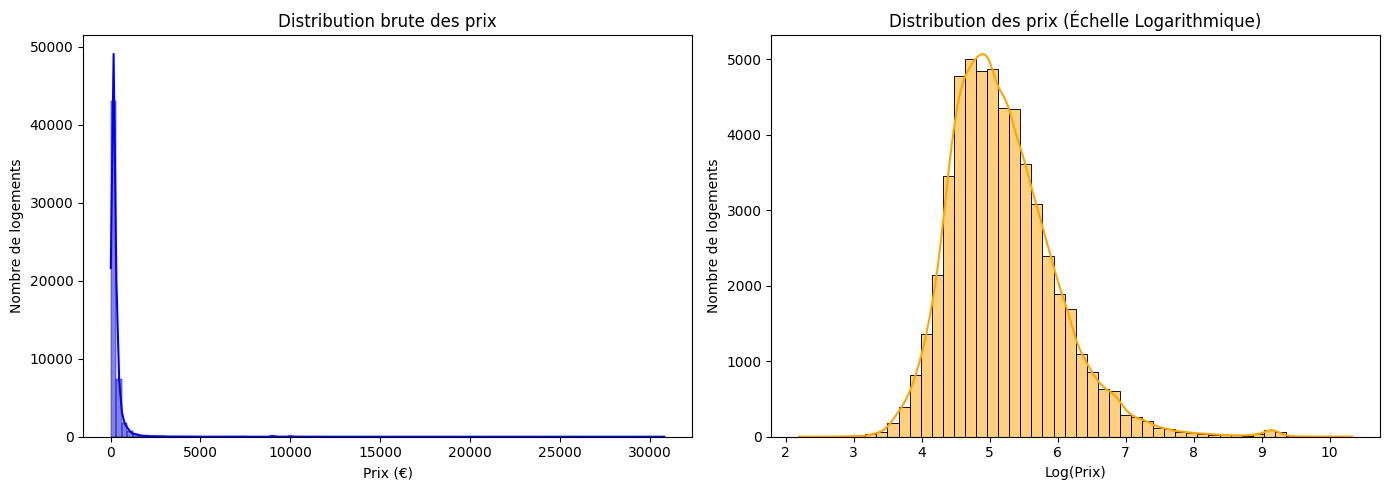

In [26]:
# Distribution des prix

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.histplot(data=df_data_copy, x='price', bins=100, kde=True, color='blue')
plt.title('Distribution brute des prix')
plt.xlabel('Prix (€)')
plt.ylabel('Nombre de logements')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df_data_copy['price'].dropna()), bins=50, kde=True, color='orange')
plt.title('Distribution des prix (Échelle Logarithmique)')
plt.xlabel('Log(Prix)')
plt.ylabel('Nombre de logements')

plt.tight_layout()
plt.show()

### Strategie Catégoritielle

In [27]:
# Sélection des colonnes de type 'object'
df_objects = df_data.select_dtypes(include=['object'])

# Afficher les premières lignes pour vérifier les valeurs
print(df_objects.head())

# Optionnel : obtenir un résumé rapide des valeurs uniques par colonne
display(df_objects.describe())

  host_response_time neighbourhood_cleansed       property_type        room_type instant_bookable
0     within an hour           Observatoire  Entire rental unit  Entire home/apt                f
1     within an hour         Hôtel-de-Ville  Entire rental unit  Entire home/apt                f
2     within an hour         Hôtel-de-Ville  Entire rental unit  Entire home/apt                f
3                NaN                  Opéra  Entire rental unit  Entire home/apt                f
4                NaN                 Louvre  Entire rental unit  Entire home/apt                f


,host_response_time,neighbourhood_cleansed,property_type,room_type,instant_bookable
count,52663,84055,84055,84055,84055
unique,4,20,58,4,2
top,within an hour,Buttes-Montmartre,Entire rental unit,Entire home/apt,f
freq,31859,8943,69871,74532,61484


In [28]:
# --- 1. DIAGNOSTIC DES COLONNES TEXTE (STR) ---
# On sélectionne uniquement les colonnes de type 'object' (texte)
cols_texte = df_data.select_dtypes(include=['object'])

print("=== VALEURS MANQUANTES (TEXTE) ===")
print(cols_texte.isna().sum())
print("\n" + "="*35 + "\n")


=== VALEURS MANQUANTES (TEXTE) ===
host_response_time        31392
neighbourhood_cleansed        0
property_type                 0
room_type                     0
instant_bookable              0
dtype: int64




In [29]:
# 
cols_object_original = df_data.select_dtypes(include=['object']).columns

cols_to_add = [col for col in cols_object_original if col not in df_data_copy.columns]

df_final = df_data_copy.join(df_data[cols_to_add])

# Vérification
print(f"Nombre de colonnes finales : {df_final.shape[1]}")
print(f"Colonnes présentes : {df_final.columns.tolist()}")

Nombre de colonnes finales : 24
Colonnes présentes : ['host_listings_count', 'host_total_listings_count', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'price', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'has_tv', 'has_kitchen', 'has_ac', 'has_fire_extinguisher', 'host_response_time', 'neighbourhood_cleansed', 'property_type', 'room_type', 'instant_bookable']


### EDA

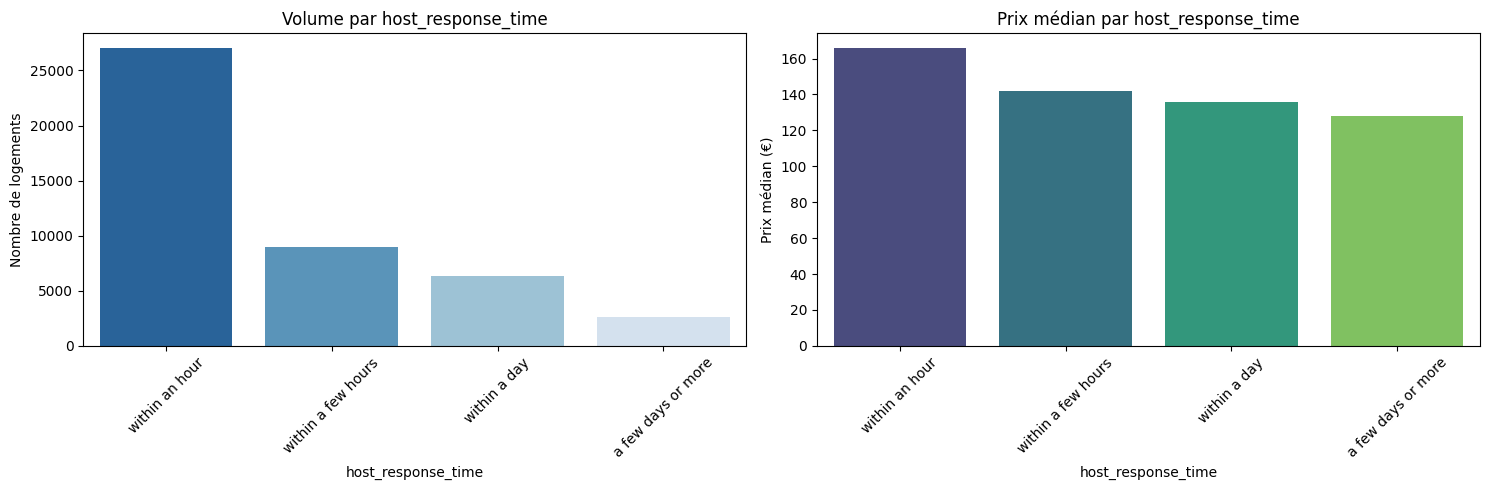

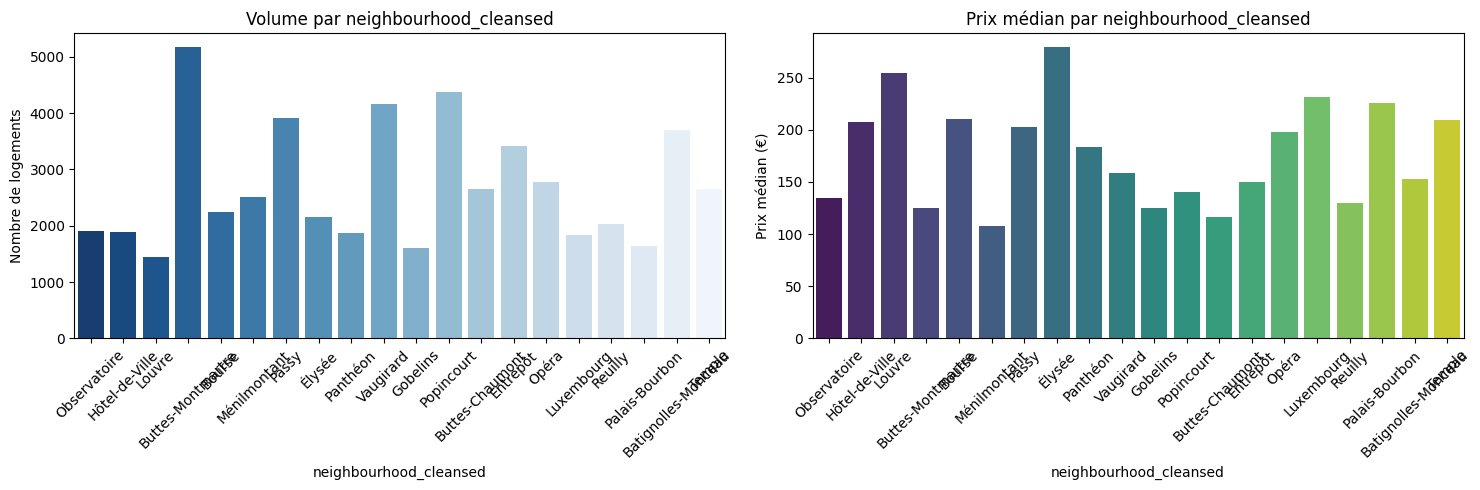

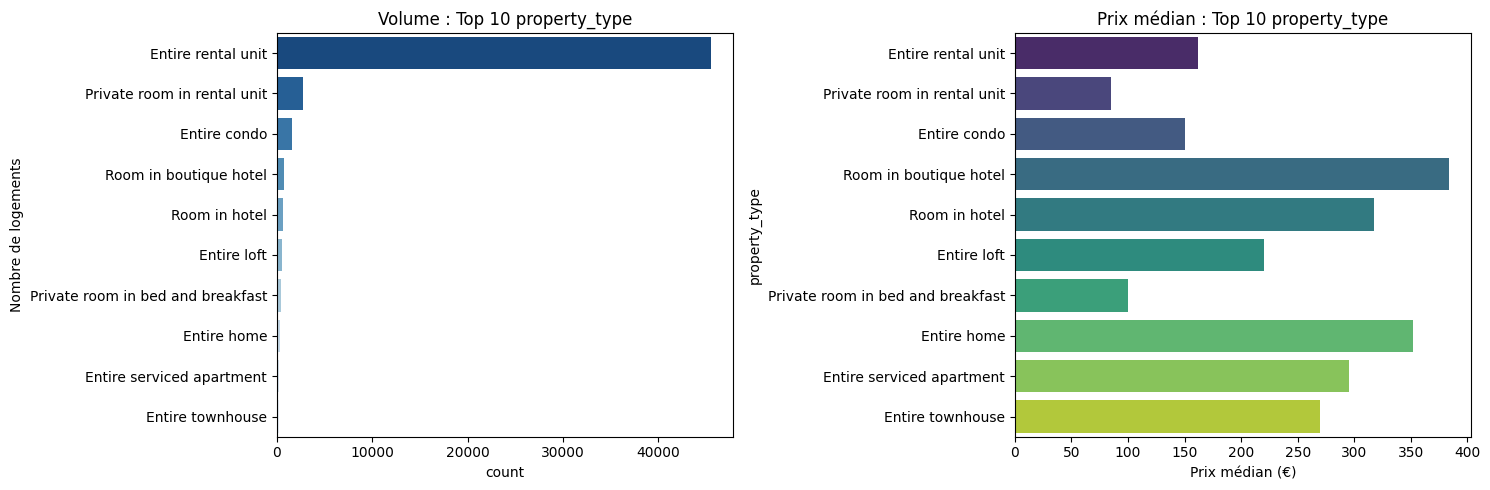

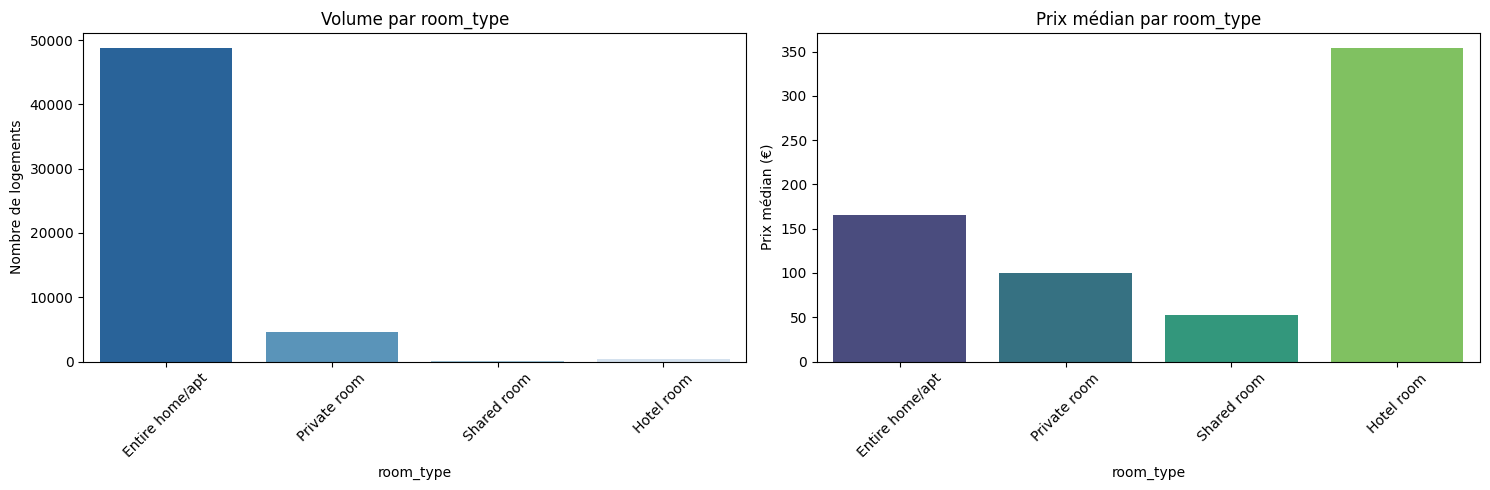

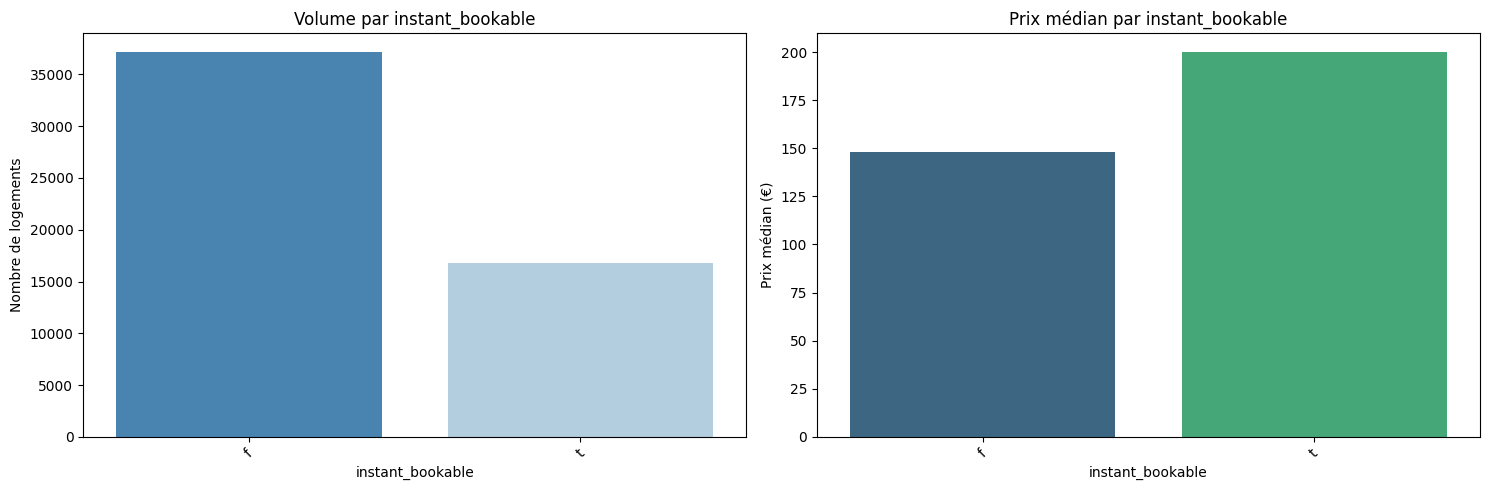

In [30]:

# Liste des variables textuelles intéressantes à explorer
cols_texte = df_final.select_dtypes(include=['object']).columns

for col in cols_texte:
    if col not in df_final.columns:
        continue
        
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)

    if col == 'property_type':
        top_10 = df_final[col].value_counts().nlargest(10).index
        data_to_plot = df_final[df_final[col].isin(top_10)]
        sns.countplot(data=data_to_plot, y=col, order=top_10, palette='Blues_r')
        plt.title(f"Volume : Top 10 {col}")
    else:
        sns.countplot(data=df_final, x=col, palette='Blues_r')
        plt.xticks(rotation=45)
        plt.title(f"Volume par {col}")
        
    plt.ylabel("Nombre de logements")

    plt.subplot(1, 2, 2)
    
    if col == 'property_type':
        sns.barplot(data=data_to_plot, y=col, x='price', estimator=np.median, errorbar=None, order=top_10, palette='viridis')
        plt.title(f"Prix médian : Top 10 {col}")
        plt.xlabel("Prix médian (€)")
    else:
        sns.barplot(data=df_final, x=col, y='price', estimator=np.median, errorbar=None, palette='viridis')
        plt.xticks(rotation=45)
        plt.title(f"Prix médian par {col}")
        plt.ylabel("Prix médian (€)")

    plt.tight_layout()
    plt.show()

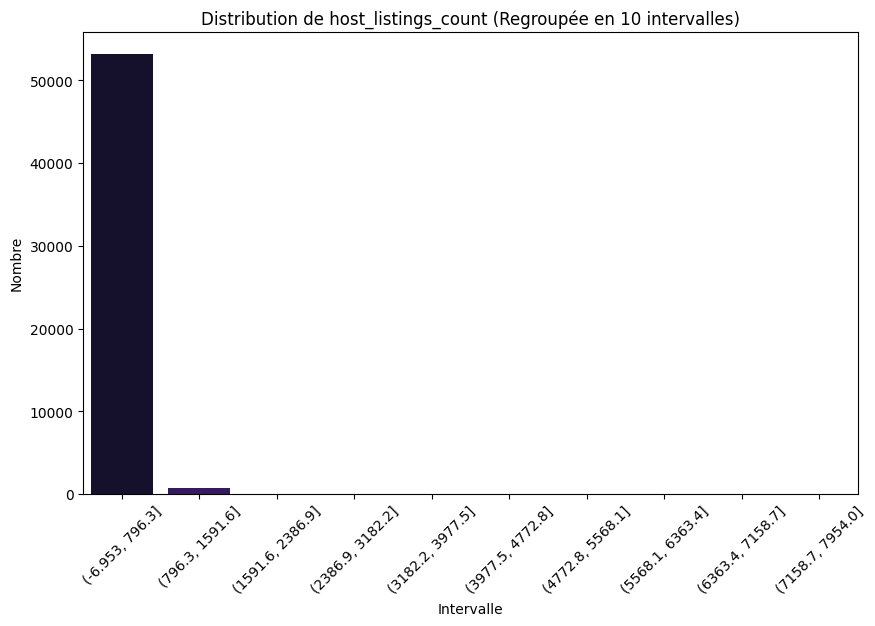

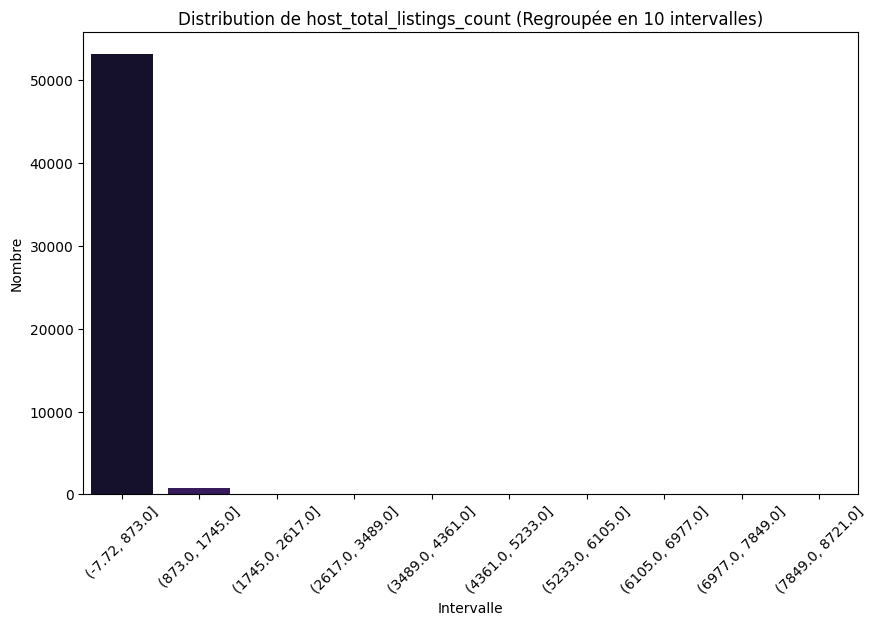

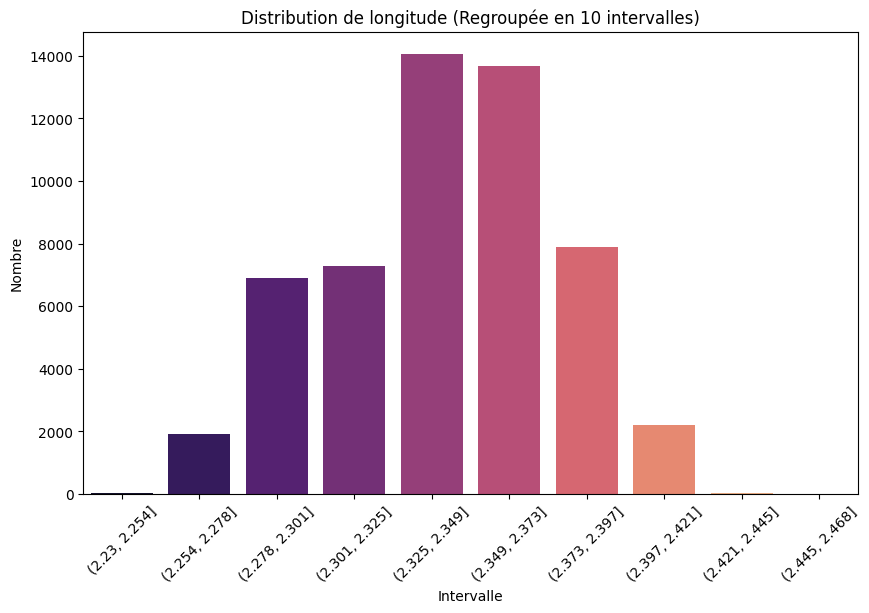

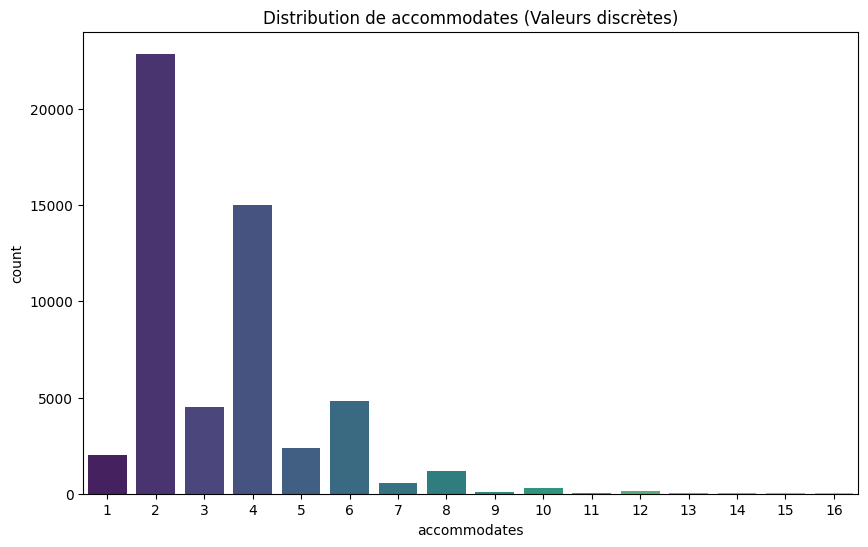

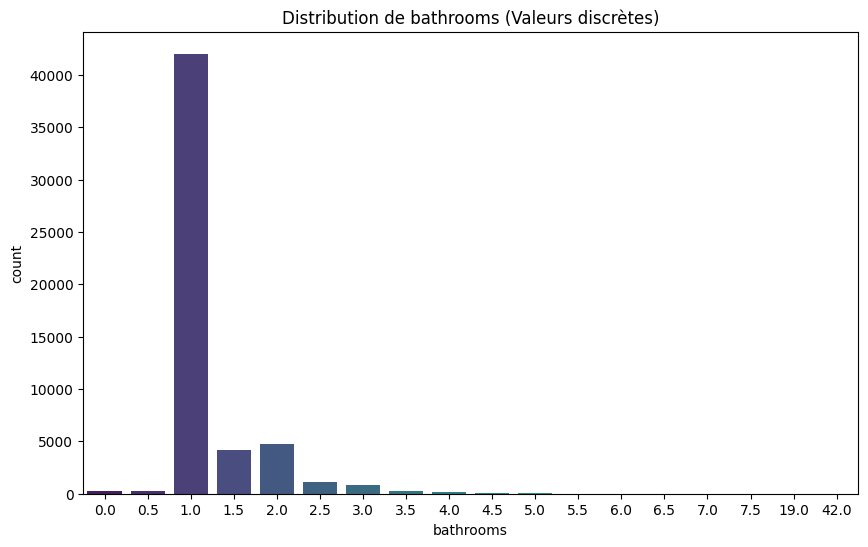

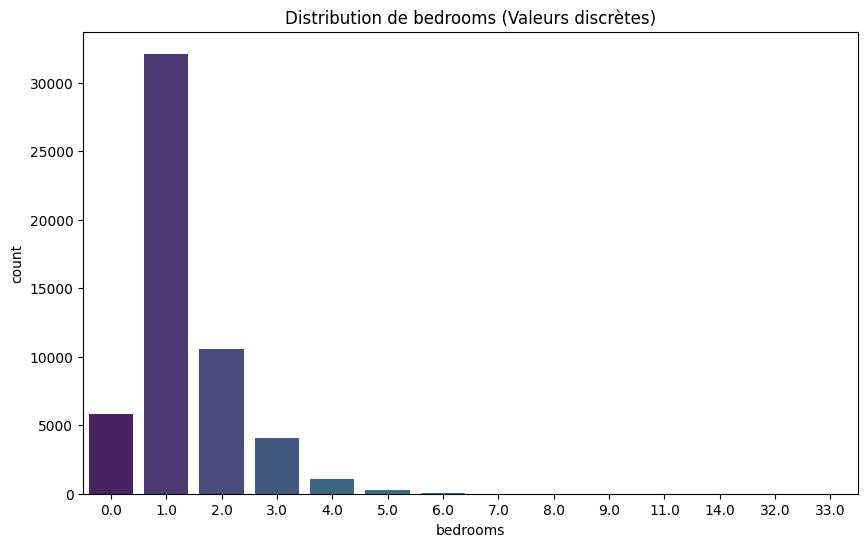

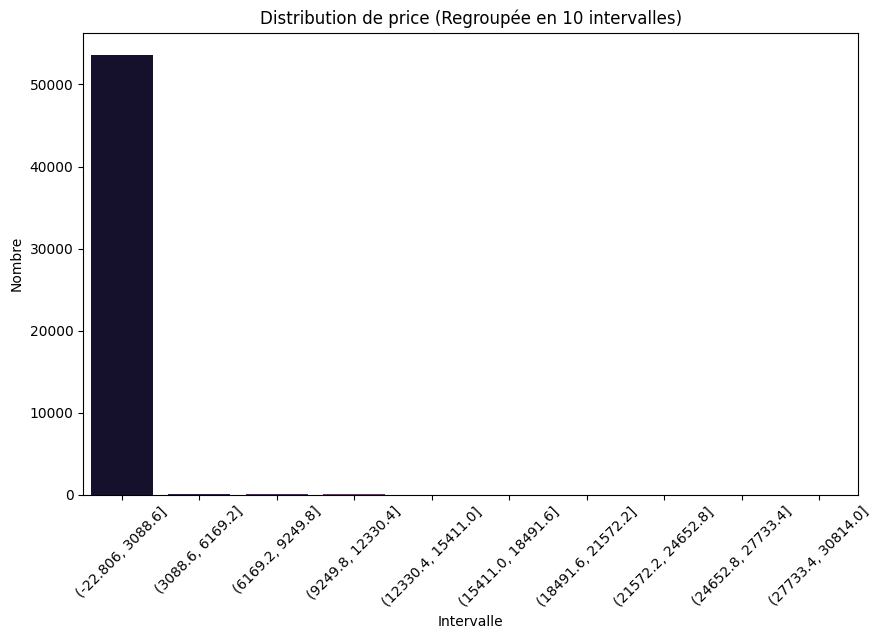

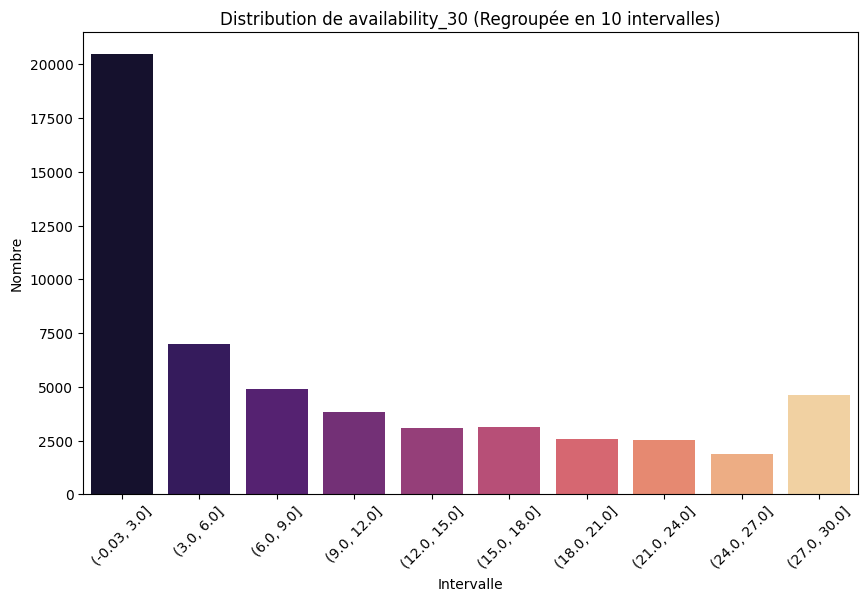

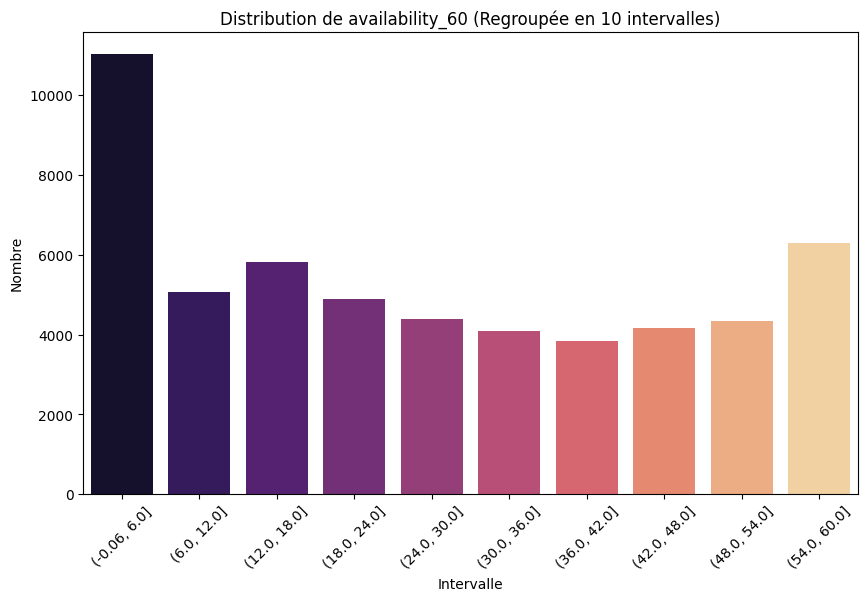

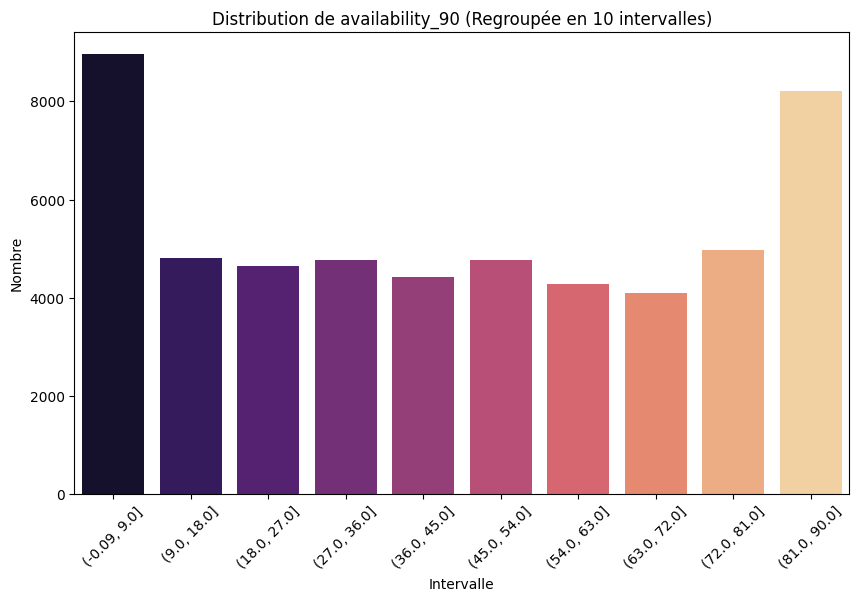

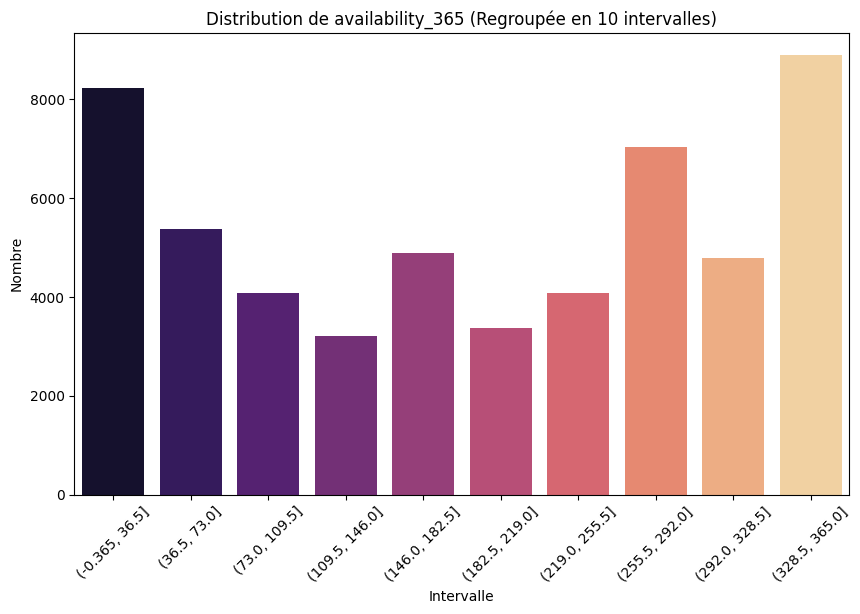

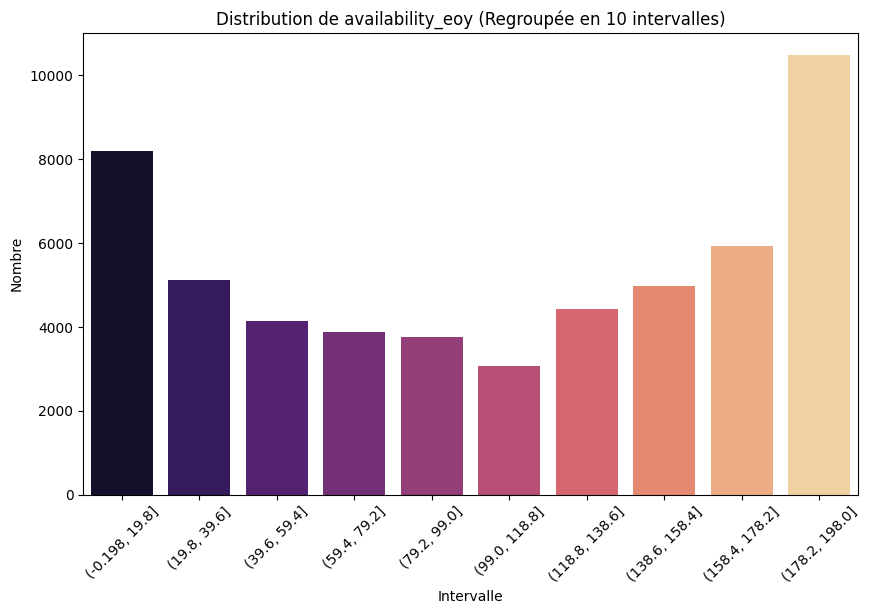

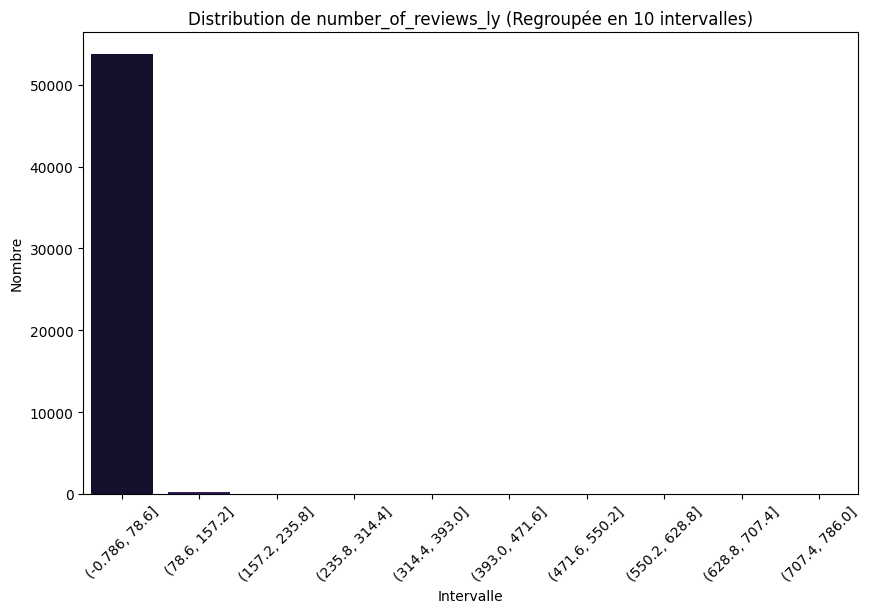

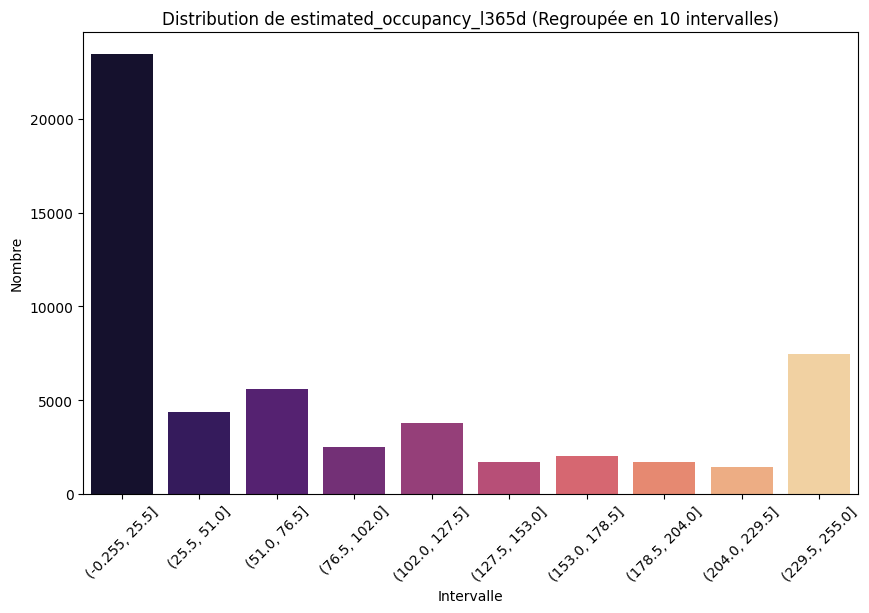

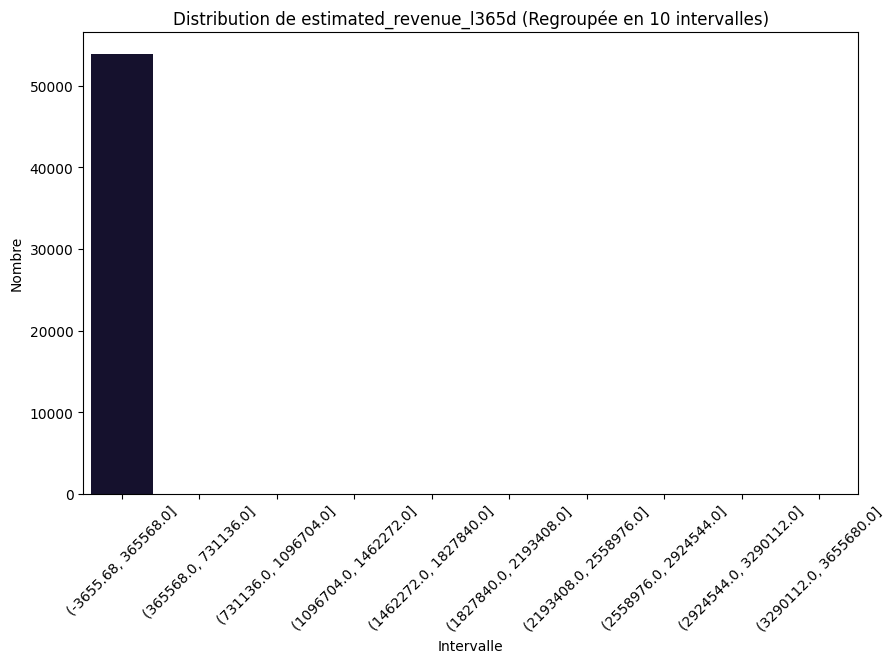

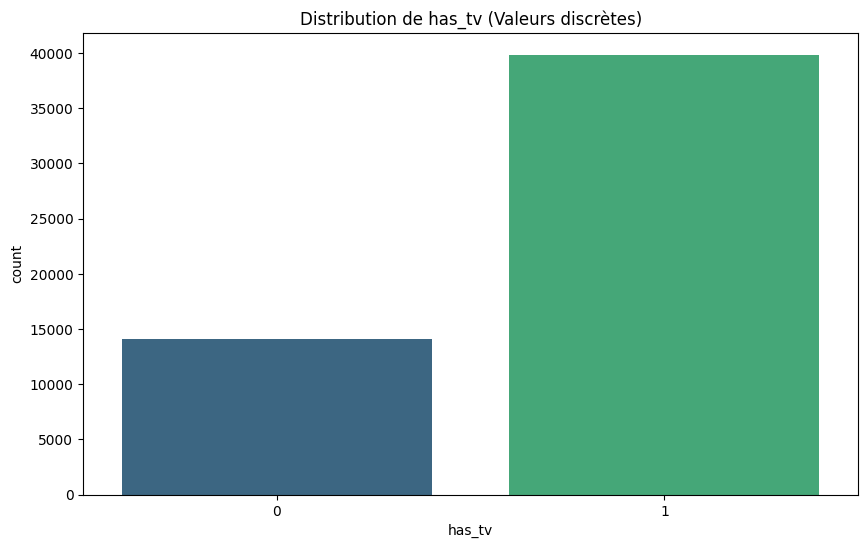

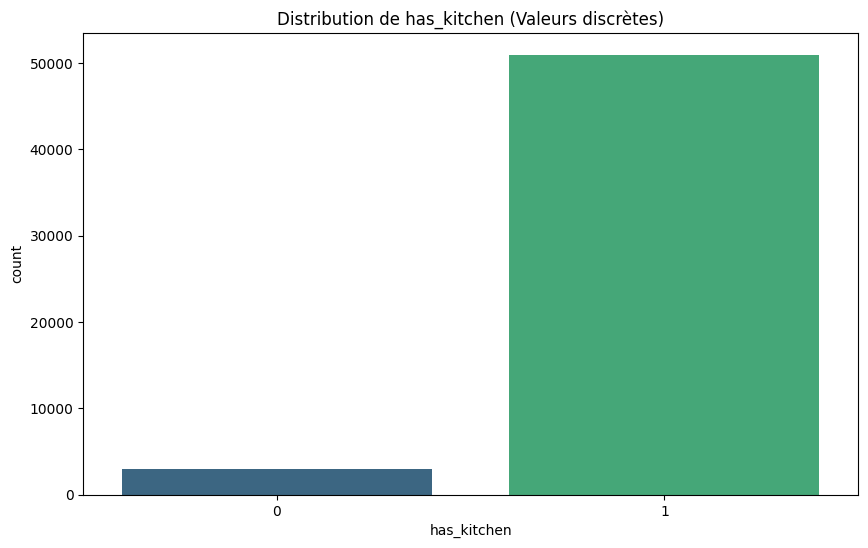

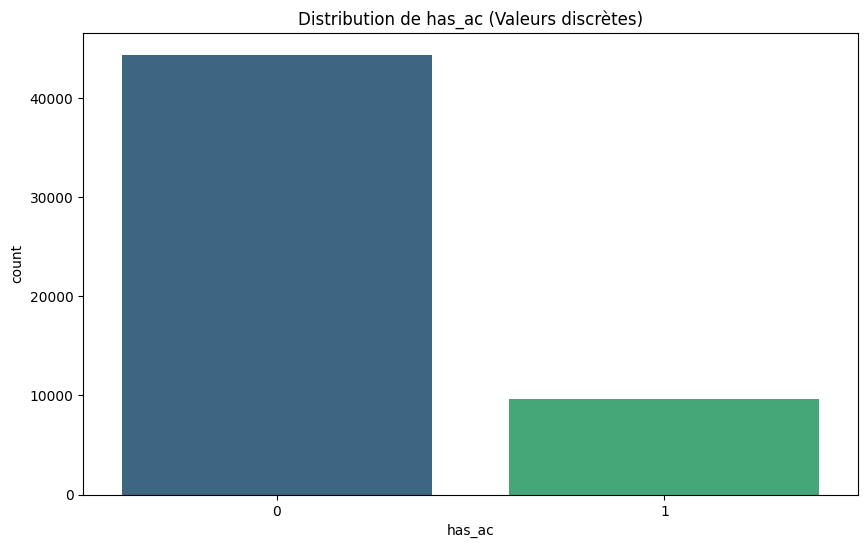

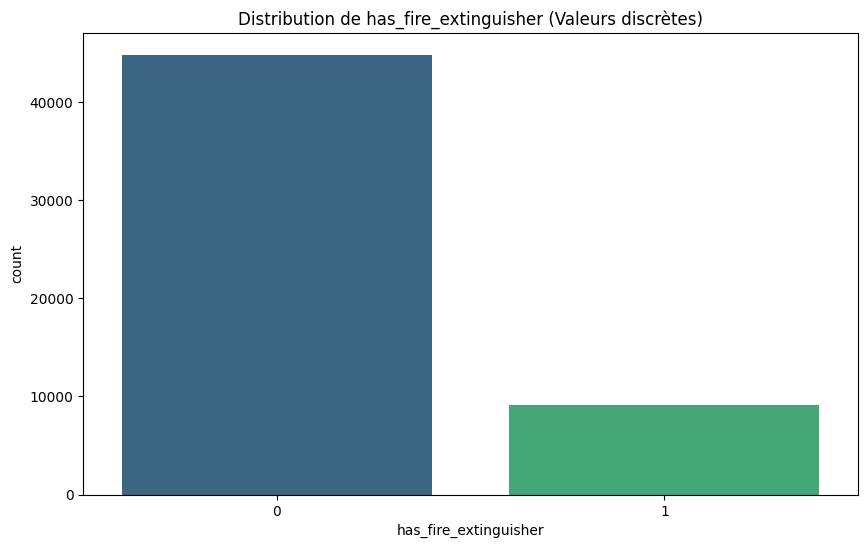

In [31]:
num_cols = df_final.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(10, 6))
    
    if df_final[col].nunique() <= 20:
        sns.countplot(x=df_final[col], data=df_final, palette='viridis')
        plt.title(f'Distribution de {col} (Valeurs discrètes)')
        
    else:
        bins = pd.cut(df_final[col], bins=10)
        counts = bins.value_counts().sort_index()
        
        df_plot = pd.DataFrame({'Intervalle': counts.index.astype(str), 'Nombre': counts.values})
        
        sns.barplot(data=df_plot, x='Intervalle', y='Nombre', palette='magma')
        plt.title(f'Distribution de {col} (Regroupée en 10 intervalles)')
        plt.xticks(rotation=45)

    plt.show()
